# Fraud Detection & Transaction Risk Scoring

**Business problem.** A lender or card issuer has to decide, for every transaction, whether to approve it, verify it or stop it.
Missing fraud costs the full transaction amount. Blocking a genuine customer costs review effort and customer goodwill.
The goal is a model that ranks transactions by fraud risk, and a decision framework that turns that ranking into actions at the lowest total cost.

**Data.** IEEE-CIS Fraud Detection (Kaggle, provided by Vesta Corporation): real card-not-present e-commerce transactions.
I use `train_transaction.csv` and `train_identity.csv` because only these have fraud labels.

**Plan.**
1. Data understanding and quality checks
2. EDA with hypothesis tests
3. Time-based split and feature engineering (no leakage)
4. Models and class-imbalance handling
5. Threshold and cost analysis
6. Risk score, tiers and decision framework
7. Interpretability and reason codes
8. SQL analysis
9. Save outputs for the dashboard / Power BI
10. Final audit

In [1]:
import sys
sys.path.append("../src")

import json
import sqlite3

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from data_preparation import load_transactions, clean_transactions
from feature_engineering import build_features, NUMERIC_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES
from risk_scoring import (cost_curve, choose_tier_thresholds, assign_tier, RISK_ACTIONS,
                          typical_values, explain_transaction, expected_cost)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

FIG_DIR = "../outputs/figures"
RESULTS_DIR = "../outputs/model_results"
RANDOM_STATE = 42

## 1. Data understanding

The raw transaction file has 394 columns. 339 of them (V1–V339) are masked features engineered by Vesta, with no documented meaning.
I load only the columns I can explain in business terms (see `src/data_preparation.py`). This is a deliberate trade-off:
some predictive power is given up so that every input to the model can be defended.

In [2]:
raw = load_transactions("../data")
print("Rows:", len(raw))
print("Columns loaded:", raw.shape[1])
raw.head()

Rows: 590540
Columns loaded: 19


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card4,card6,addr1,dist1,P_emaildomain,R_emaildomain,C1,C13,C14,D1,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5000,W,13926,discover,credit,315.0000,19.0000,NaN,NaN,1.0000,1.0000,1.0000,14.0000,NaN,NaN,0
1,2987001,0,86401,29.0000,W,2755,mastercard,credit,325.0000,NaN,gmail.com,NaN,1.0000,1.0000,1.0000,0.0000,NaN,NaN,0
2,2987002,0,86469,59.0000,W,4663,visa,debit,330.0000,287.0000,outlook.com,NaN,1.0000,1.0000,1.0000,0.0000,NaN,NaN,0
3,2987003,0,86499,50.0000,W,18132,mastercard,debit,476.0000,NaN,yahoo.com,NaN,2.0000,25.0000,1.0000,112.0000,NaN,NaN,0
4,2987004,0,86506,50.0000,H,4497,mastercard,credit,420.0000,NaN,gmail.com,NaN,1.0000,1.0000,1.0000,0.0000,mobile,SAMSUNG SM-G892A Build/NRD90M,1


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionID   590540 non-null  int64  
 1   isFraud         590540 non-null  int64  
 2   TransactionDT   590540 non-null  int64  
 3   TransactionAmt  590540 non-null  float64
 4   ProductCD       590540 non-null  str    
 5   card1           590540 non-null  int64  
 6   card4           588963 non-null  str    
 7   card6           588969 non-null  str    
 8   addr1           524834 non-null  float64
 9   dist1           238269 non-null  float64
 10  P_emaildomain   496084 non-null  str    
 11  R_emaildomain   137291 non-null  str    
 12  C1              590540 non-null  float64
 13  C13             590540 non-null  float64
 14  C14             590540 non-null  float64
 15  D1              589271 non-null  float64
 16  DeviceType      140810 non-null  str    
 17  DeviceInfo      11866

In [4]:
missing_pct = raw.isna().mean().mul(100).round(1).sort_values(ascending=False)
missing_pct[missing_pct > 0]

DeviceInfo      79.9000
R_emaildomain   76.8000
DeviceType      76.2000
dist1           59.7000
P_emaildomain   16.0000
addr1           11.1000
card6            0.3000
card4            0.3000
D1               0.2000
dtype: float64

**Reading the missing values.** Missing values here are mostly *structural*, not errors:
`DeviceType`/`DeviceInfo` are missing when there is no identity record, `dist1` is only recorded for some products,
and a missing email domain means the customer didn't provide one. I keep them as information instead of dropping rows.

In [5]:
print("Duplicate rows:          ", raw.duplicated().sum())
print("Duplicate TransactionID: ", raw["TransactionID"].duplicated().sum())
print("Missing card1:           ", raw["card1"].isna().sum())

Duplicate rows:           0
Duplicate TransactionID:  0
Missing card1:            0


In [6]:
raw.nunique().sort_values()

isFraud                2
DeviceType             2
has_identity           2
card6                  4
card4                  4
ProductCD              5
P_emaildomain         59
R_emaildomain         60
addr1                332
D1                   641
C14                 1108
C13                 1597
C1                  1657
DeviceInfo          1786
dist1               2651
card1              13553
TransactionAmt     20902
TransactionDT     573349
TransactionID     590540
dtype: int64

### Target distribution

In [7]:
fraud_rate = raw["isFraud"].mean()
fraud_amount = raw.loc[raw["isFraud"] == 1, "TransactionAmt"].sum()
total_amount = raw["TransactionAmt"].sum()

print(raw["isFraud"].value_counts())
print(f"Fraud rate by count: {fraud_rate:.2%}")
print(f"Fraud share by value: {fraud_amount / total_amount:.2%}  (${fraud_amount:,.0f} of ${total_amount:,.0f})")
print(f"Accuracy of a model that never predicts fraud: {1 - fraud_rate:.2%}")

isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate by count: 3.50%
Fraud share by value: 3.87%  ($3,083,845 of $79,738,949)
Accuracy of a model that never predicts fraud: 96.50%


A model that says "never fraud" is already highly accurate and catches nothing. Accuracy will not be used to choose models.

### Financial data-quality checks

In [8]:
print("Amount <= 0:", (raw["TransactionAmt"] <= 0).sum())
raw["TransactionAmt"].describe(percentiles=[0.01, 0.5, 0.95, 0.99, 0.999])

Amount <= 0: 0


count   590,540.0000
mean        135.0272
std         239.1625
min           0.2510
1%            9.2440
50%          68.7690
95%         445.0000
99%       1,104.0000
99.9%     2,769.8073
max      31,937.3910
Name: TransactionAmt, dtype: float64

In [9]:
# TransactionDT is seconds from an undisclosed reference date
span_days = (raw["TransactionDT"].max() - raw["TransactionDT"].min()) / 86400
print(f"Time span covered: {span_days:.0f} days")
print("TransactionDT is increasing after sort:", raw["TransactionDT"].is_monotonic_increasing)
print("Negative TransactionDT:", (raw["TransactionDT"] < 0).sum())

Time span covered: 182 days
TransactionDT is increasing after sort: True
Negative TransactionDT: 0


In [10]:
for col in ["ProductCD", "card4", "card6", "DeviceType"]:
    print(col, raw[col].value_counts(dropna=False).to_dict())

ProductCD {'W': 439670, 'C': 68519, 'R': 37699, 'H': 33024, 'S': 11628}
card4 {'visa': 384767, 'mastercard': 189217, 'american express': 8328, 'discover': 6651, nan: 1577}
card6 {'debit': 439938, 'credit': 148986, nan: 1571, 'debit or credit': 30, 'charge card': 15}
DeviceType {nan: 449730, 'desktop': 85165, 'mobile': 55645}


In [11]:
# Extreme amounts: error, legitimate large purchase, or fraud signal?
top_amounts = raw.nlargest(10, "TransactionAmt")[["TransactionID", "TransactionDT", "TransactionAmt", "ProductCD", "card1", "isFraud"]]
top_amounts

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,isFraud
274336,3261336,6652360,"31,937.3910",W,16075,0
274339,3261339,6652391,"31,937.3910",W,16075,0
296021,3283021,7320188,"6,450.9700",W,16661,0
248413,3235413,5926506,"6,085.2300",W,2755,0
384603,3371603,9648912,"5,543.2300",W,11106,0
275529,3262529,6706260,"5,420.0000",W,5033,0
275535,3262535,6706356,"5,420.0000",W,5033,0
584767,3571767,15632496,"5,366.8200",W,7585,0
303106,3290106,7501413,"5,279.9500",W,12583,0
315172,3302172,7850500,"5,279.9500",W,11106,0


In [12]:
amount_decile = pd.qcut(raw["TransactionAmt"], q=10, duplicates="drop")
raw.groupby(amount_decile, observed=True)["isFraud"].agg(["count", "mean"])

,count,mean
TransactionAmt,,
"(0.25, 25.95]",59511,0.0559
"(25.95, 35.95]",61650,0.0321
"(35.95, 49.0]",65116,0.0323
"(49.0, 57.95]",59647,0.0194
"(57.95, 68.769]",49346,0.0285
"(68.769, 100.0]",73349,0.0362
"(100.0, 117.0]",72079,0.0197
"(117.0, 159.95]",32399,0.0430
"(159.95, 275.293]",58390,0.0380


**Decision on outliers.** Very large amounts are not removed. They are positive, well-formed transactions, so they are not data errors,
and the fraud rate across amount bands shows whether size itself carries risk. For modelling I use `log(amount)` so a few
extreme values don't dominate the linear model, instead of deleting them.

In [13]:
df = clean_transactions(raw)

## 2. Exploratory analysis — business questions

Each chart answers one question and ends with what it means for the model or the business.
Where a difference could be random noise, I test it formally.

### Q1. Do fraudulent transactions have different amounts?

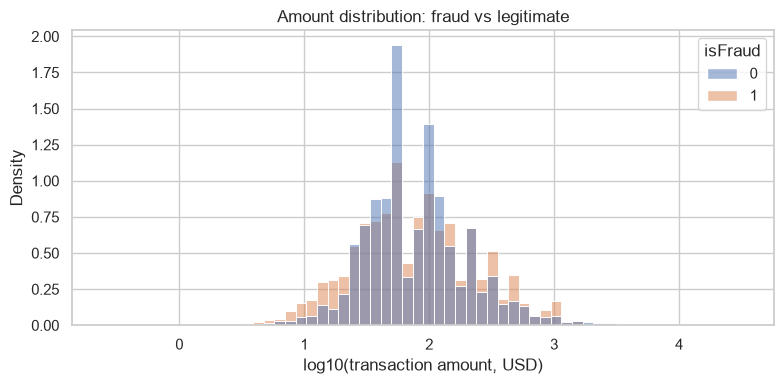

isFraud
0   68.5000
1   75.0000
Name: TransactionAmt, dtype: float64
Mann-Whitney U p-value: 2.26e-01


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x=np.log10(df["TransactionAmt"]), hue="isFraud", stat="density",
             common_norm=False, bins=60, ax=ax)
ax.set_xlabel("log10(transaction amount, USD)")
ax.set_title("Amount distribution: fraud vs legitimate")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_amount_distribution.png", dpi=120)
plt.show()

print(df.groupby("isFraud")["TransactionAmt"].median())

# Amounts are heavily skewed, so I use a rank-based test instead of a t-test
fraud_amts = df.loc[df["isFraud"] == 1, "TransactionAmt"]
legit_amts = df.loc[df["isFraud"] == 0, "TransactionAmt"]
stat, p_value = mannwhitneyu(fraud_amts, legit_amts)
print(f"Mann-Whitney U p-value: {p_value:.2e}")

*Interpretation:* if the distributions overlap heavily, amount alone cannot separate fraud, and a simple
"block large transactions" rule would mostly block genuine customers. Amount is useful mainly **relative to the customer's own history**, which motivates `amt_to_uid_avg`.

### Q2. Are some products and card types riskier?

,transactions,fraud_rate
ProductCD,,
C,68519,0.1169
S,11628,0.0590
H,33024,0.0477
R,37699,0.0378
W,439670,0.0204


,transactions,fraud_rate
card6,,
credit,148986,0.0668
missing,1571,0.0248
debit,439938,0.0243
charge card,15,0.0000
debit or credit,30,0.0000


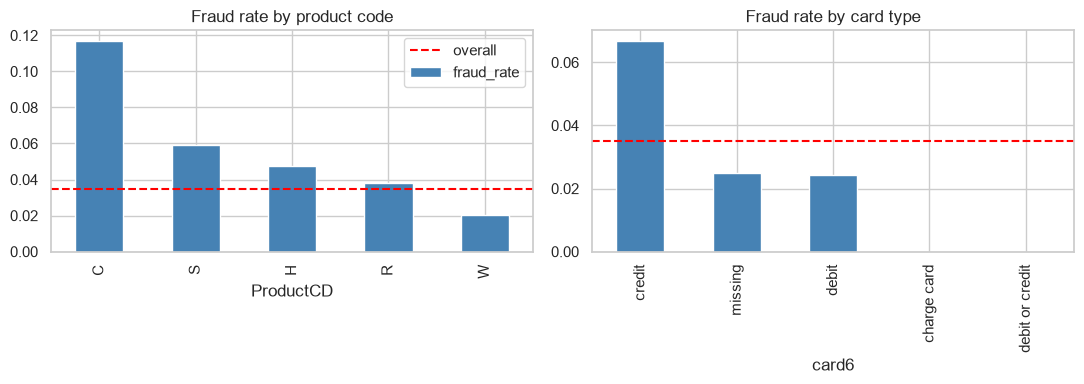

Chi-square test, ProductCD vs fraud: p-value = 0.00e+00


In [15]:
def fraud_rate_table(data, col):
    table = data.groupby(col)["isFraud"].agg(transactions="count", fraud_rate="mean")
    return table.sort_values("fraud_rate", ascending=False)

product_table = fraud_rate_table(df, "ProductCD")
card_type_table = fraud_rate_table(df, "card6")
display(product_table)
display(card_type_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
product_table["fraud_rate"].plot.bar(ax=axes[0], color="steelblue")
axes[0].axhline(fraud_rate, color="red", linestyle="--", label="overall")
axes[0].set_title("Fraud rate by product code")
axes[0].legend()
card_type_table["fraud_rate"].plot.bar(ax=axes[1], color="steelblue")
axes[1].axhline(fraud_rate, color="red", linestyle="--")
axes[1].set_title("Fraud rate by card type")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_fraud_by_product_card.png", dpi=120)
plt.show()

chi2, p_value, dof, _ = chi2_contingency(pd.crosstab(df["ProductCD"], df["isFraud"]))
print(f"Chi-square test, ProductCD vs fraud: p-value = {p_value:.2e}")

*Interpretation:* product segments with a fraud rate well above average are candidates for stricter default checks.
Product is kept as a model feature. For a lender this is the same idea as setting different risk appetites per loan product.

### Q3. Does fraud vary by time of day?

The reference date and time zone are not disclosed, so "hour" is relative. I can still find the hours when activity is lowest.

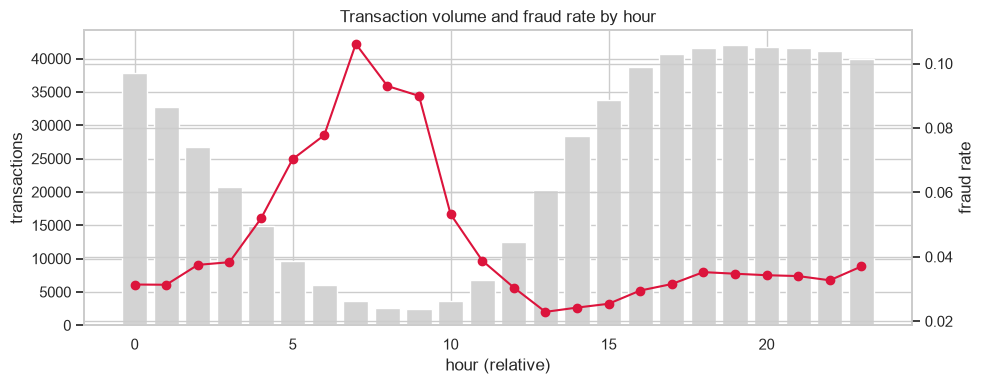

Correlation between hourly volume and hourly fraud rate: -0.73


In [16]:
hourly = df.groupby("hour")["isFraud"].agg(transactions="count", fraud_rate="mean")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(hourly.index, hourly["transactions"], color="lightgrey", label="transactions")
ax1.set_ylabel("transactions")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_rate"], color="crimson", marker="o", label="fraud rate")
ax2.set_ylabel("fraud rate")
ax1.set_xlabel("hour (relative)")
ax1.set_title("Transaction volume and fraud rate by hour")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_fraud_by_hour.png", dpi=120)
plt.show()

print("Correlation between hourly volume and hourly fraud rate:",
      round(hourly["transactions"].corr(hourly["fraud_rate"]), 2))

*Interpretation:* if fraud rate rises when genuine volume is low, quiet hours are riskier. This becomes `quiet_hour_flag`.
The quiet hours are chosen from the **training period only**, in section 3.

### Q4. Alternate data: do email domain and device tell us anything?

The JD talks about using alternate data for underwriting. Email domain and device information are exactly that:
they are not financial variables, but they describe how the customer is interacting.

,transactions,fraud_rate
email_group,,
microsoft,59477,0.0533
gmail,228851,0.0435
missing,94456,0.0295
other,37164,0.0243
anonymous,36998,0.0232
yahoo,105305,0.0225
aol,28289,0.0218


,transactions,fraud_rate
DeviceType,,
mobile,55645,0.1017
desktop,85165,0.0652
missing,449730,0.0210


,transactions,fraud_rate
has_identity,,
1,140810,0.0796
0,449730,0.0210


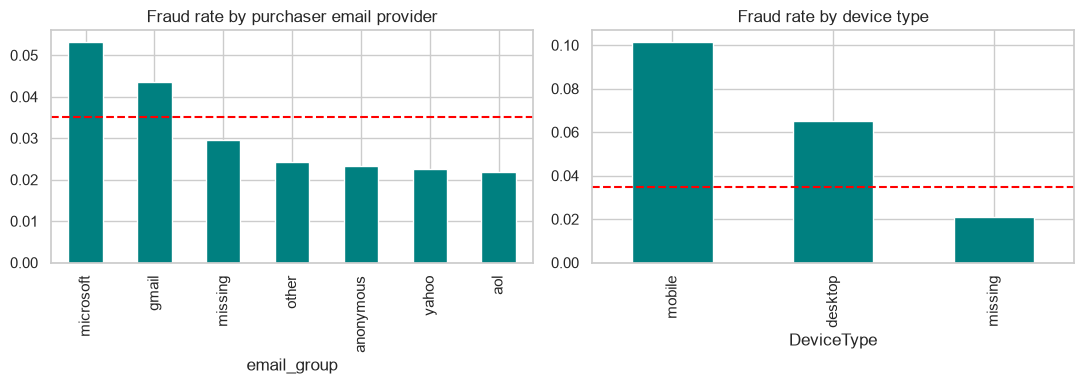

Chi-square test, email provider vs fraud: p-value = 0.00e+00


In [17]:
from feature_engineering import group_email

df["email_group"] = df["P_emaildomain"].apply(group_email)
email_table = fraud_rate_table(df, "email_group")
device_table = fraud_rate_table(df, "DeviceType")
identity_table = fraud_rate_table(df, "has_identity")
display(email_table)
display(device_table)
display(identity_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
email_table["fraud_rate"].plot.bar(ax=axes[0], color="teal")
axes[0].axhline(fraud_rate, color="red", linestyle="--")
axes[0].set_title("Fraud rate by purchaser email provider")
device_table["fraud_rate"].plot.bar(ax=axes[1], color="teal")
axes[1].axhline(fraud_rate, color="red", linestyle="--")
axes[1].set_title("Fraud rate by device type")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_alternate_data.png", dpi=120)
plt.show()

chi2, p_value, dof, _ = chi2_contingency(pd.crosstab(df["email_group"], df["isFraud"]))
print(f"Chi-square test, email provider vs fraud: p-value = {p_value:.2e}")

*Interpretation:* with ~590k rows almost any difference is "statistically significant", so the p-value only rules out noise.
What matters is the **size** of the difference in fraud rate and how many transactions it affects.

### Q5. Is fraud stable over time?

This decides how the data must be split. If fraud patterns drift, a random split would let the model see the future.

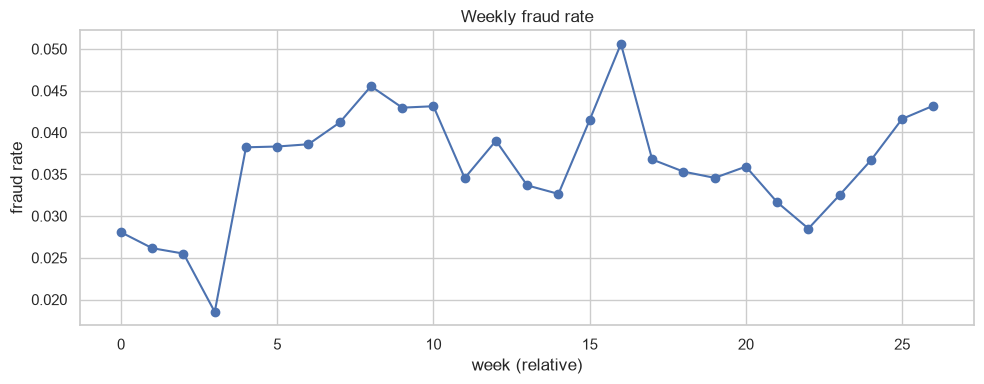

Weekly fraud rate ranges from 1.85% to 5.06%


In [18]:
weekly = df.groupby(df["day"] // 7)["isFraud"].agg(transactions="count", fraud_rate="mean")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly.index, weekly["fraud_rate"], marker="o")
ax.set_xlabel("week (relative)")
ax.set_ylabel("fraud rate")
ax.set_title("Weekly fraud rate")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_weekly_fraud_rate.png", dpi=120)
plt.show()

print(f"Weekly fraud rate ranges from {weekly['fraud_rate'].min():.2%} to {weekly['fraud_rate'].max():.2%}")

*Interpretation:* fraud rate moves week to week, so the model must be tested on a **later** period than it was trained on.
That is how it would be used in production.

## 3. Time-based split and feature engineering

### Split
Rows are sorted by `TransactionDT` and split by time:

| Set | Share | Used for |
|---|---|---|
| Train | first 70% | fitting models |
| Validation | next 15% | comparing models, choosing thresholds and tiers |
| Test | last 15% | one final check, never used for any decision |

### Avoiding leakage
- **History features** (customer's transaction count, average amount, time since last transaction) are computed with the data
  sorted by time, using only transactions **strictly before** the current one (`cumcount`, `diff`, `cumsum - current amount`, a 24h look-back window).
  Computing them over the full timeline is safe because a test transaction may look back into training months (the bank has that history) but never forward.
- **Cut-offs** that are learned from data (quiet hours, high-value amount) are calculated on the training period only.
- **Labels** are never used to build features.

In [19]:
n_rows = len(df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_cutoff_dt = df["TransactionDT"].iloc[train_end]
val_cutoff_dt = df["TransactionDT"].iloc[val_end]

train_period = df[df["TransactionDT"] < train_cutoff_dt]

# Quiet hours: the 6 hours with the lowest transaction volume in the training period
hourly_volume_train = train_period.groupby("hour").size()
quiet_hours = hourly_volume_train.nsmallest(6).index.tolist()

# High-value: top 1% of training amounts
high_value_cutoff = train_period["TransactionAmt"].quantile(0.99)

print("Quiet hours (relative):", sorted(quiet_hours))
print(f"High-value cut-off: ${high_value_cutoff:,.2f}")

Quiet hours (relative): [6, 7, 8, 9, 10, 11]
High-value cut-off: $1,104.00


In [20]:
df = build_features(df, quiet_hours, high_value_cutoff)

df["split"] = "train"
df.loc[df["TransactionDT"] >= train_cutoff_dt, "split"] = "validation"
df.loc[df["TransactionDT"] >= val_cutoff_dt, "split"] = "test"

df.groupby("split", sort=False).agg(
    rows=("isFraud", "size"),
    fraud_rate=("isFraud", "mean"),
    first_day=("day", "min"),
    last_day=("day", "max"),
)

,rows,fraud_rate,first_day,last_day
split,,,,
train,413378,0.0352,1,120
validation,88581,0.0343,120,152
test,88581,0.0348,152,182


### Feature list

| Feature | Business meaning |
|---|---|
| `log_amt` | Transaction size, log-scaled because amounts are skewed |
| `hour`, `quiet_hour_flag` | Activity at unusual times |
| `card_age_days` (D1) | How long the card has been in use. New cards are a classic fraud signal, like new-to-credit borrowers |
| `dist1`, `addr_missing` | Distance data / missing billing address |
| `C1`, `C13`, `C14` | Masked "counting" features (e.g. how many addresses are linked to the card). Used as-is and flagged as less interpretable |
| `has_identity`, `DeviceType` | Whether device information was captured, and which kind |
| `email_group`, `email_mismatch` | Purchaser email provider; purchaser and recipient emails differ |
| `ProductCD`, `card4`, `card6` | Product segment, card network, credit vs debit |
| `uid_txn_count_prior` | How many earlier transactions this customer has |
| `uid_txn_count_24h` | Velocity: transactions by this customer in the previous 24 hours |
| `log_secs_since_last_txn`, `rapid_txn_flag` | Time since the customer's last transaction; flag if under 5 minutes |
| `amt_to_uid_avg` | This amount divided by the customer's average past amount |
| `is_new_uid` | No earlier history for this customer |
| `high_value_flag` | Amount above the training 99th percentile |

**Customer ID.** The data has no customer ID. `uid = card1 + addr1 + (day − D1)` groups transactions from the same card, billing address and card start date.
This proxy is widely used for this dataset. It is approximate, and this is stated as a limitation.

In [21]:
# Sanity checks that history features only use the past
first_txn_per_customer = df.groupby("uid").head(1)
print("Max prior count on a customer's first transaction:", first_txn_per_customer["uid_txn_count_prior"].max())
print("amt_to_uid_avg on first transactions is always 1:", np.allclose(first_txn_per_customer["amt_to_uid_avg"], 1))
print("Customers (proxy):", df["uid"].nunique())

Max prior count on a customer's first transaction: 0
amt_to_uid_avg on first transactions is always 1: True
Customers (proxy): 217779


### Q6. Do the behavioural features separate fraud? (training period only)

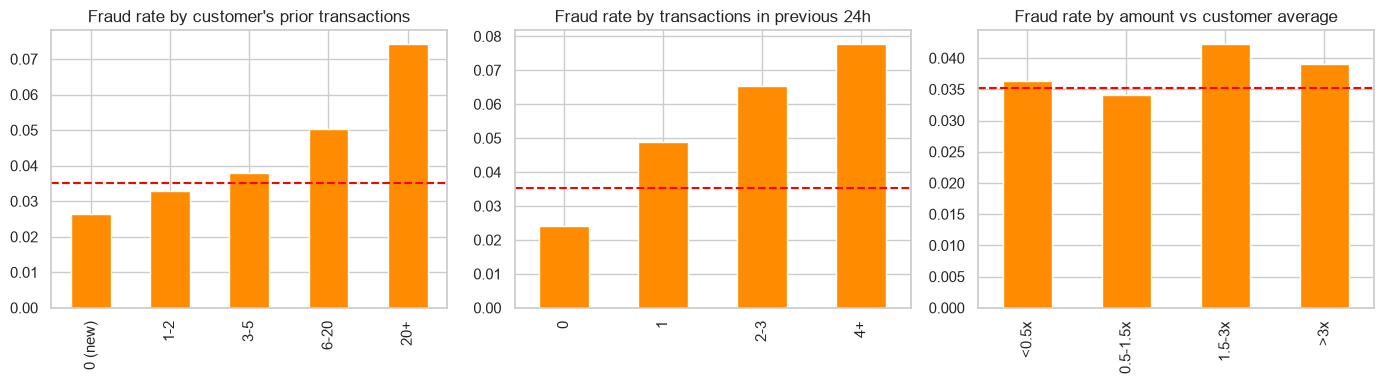

In [22]:
train_df = df[df["split"] == "train"]

history_bucket = pd.cut(train_df["uid_txn_count_prior"], bins=[-1, 0, 2, 5, 20, np.inf],
                        labels=["0 (new)", "1-2", "3-5", "6-20", "20+"])
velocity_bucket = pd.cut(train_df["uid_txn_count_24h"], bins=[-1, 0, 1, 3, np.inf],
                         labels=["0", "1", "2-3", "4+"])
ratio_bucket = pd.cut(train_df["amt_to_uid_avg"], bins=[0, 0.5, 1.5, 3, np.inf],
                      labels=["<0.5x", "0.5-1.5x", "1.5-3x", ">3x"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
train_df.groupby(history_bucket, observed=True)["isFraud"].mean().plot.bar(ax=axes[0], color="darkorange")
axes[0].set_title("Fraud rate by customer's prior transactions")
train_df.groupby(velocity_bucket, observed=True)["isFraud"].mean().plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Fraud rate by transactions in previous 24h")
train_df.groupby(ratio_bucket, observed=True)["isFraud"].mean().plot.bar(ax=axes[2], color="darkorange")
axes[2].set_title("Fraud rate by amount vs customer average")
for ax in axes:
    ax.axhline(train_df["isFraud"].mean(), color="red", linestyle="--")
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_behavioural_features.png", dpi=120)
plt.show()

## 4. Models and class imbalance

**Why these models**

| Model | What it learns | Strengths | Weaknesses |
|---|---|---|---|
| Logistic Regression | A weighted sum of features → probability | Fully interpretable coefficients, fast, the standard baseline in credit risk | Only straight-line relationships unless features are engineered |
| Decision Tree (depth 6) | If-then rules | Rules can be read by a business user | Unstable, overfits easily |
| Random Forest | Average of many trees on random subsets | Captures interactions, robust | Slower, less transparent |
| Hist Gradient Boosting | Trees built one after another, each fixing the last one's errors | Usually the strongest on tabular data, fast on large data | Needs care to avoid overfitting, least transparent |

Gradient boosting is included because it is what most fraud and credit teams use in practice on large tabular data.
It is kept only if it clearly beats Random Forest on validation.

**Imbalance.** I compare no weighting vs `class_weight="balanced"`, which makes each missed fraud count as much as many false alarms during training.
SMOTE is not used: it creates synthetic fraud rows by interpolating between real ones, which here would mix the history features of different
customers and time points into transactions that could never exist. With ~20k real fraud cases, we don't lack examples.

**Model selection metric.** Validation PR-AUC (average precision). It measures how well the model ranks fraud above legitimate transactions
with no dependence on the huge number of easy negatives. ROC-AUC is also reported, but it can look good even when alerts are mostly false.

In [23]:
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]

X_train, y_train = train_df[ALL_FEATURES], train_df["isFraud"]
X_val, y_val = val_df[ALL_FEATURES], val_df["isFraud"]
X_test, y_test = test_df[ALL_FEATURES], test_df["isFraud"]

# One preprocessing step shared by all models. Scaling doesn't affect trees but is
# needed for logistic regression, so using the same pipeline keeps things simple.
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

models = {
    "Logistic Regression (no weights)": LogisticRegression(max_iter=1000),
    "Logistic Regression (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree (balanced)": DecisionTreeClassifier(max_depth=6, min_samples_leaf=200,
                                                       class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=50,
                                                       max_samples=0.5, class_weight="balanced_subsample",
                                                       n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting (balanced)": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                                   max_leaf_nodes=31, class_weight="balanced",
                                                                   random_state=RANDOM_STATE),
}

In [24]:
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    train_scores = pipe.predict_proba(X_train)[:, 1]
    val_scores = pipe.predict_proba(X_val)[:, 1]
    val_pred = (val_scores >= 0.5).astype(int)

    results.append({
        "model": name,
        "train_pr_auc": average_precision_score(y_train, train_scores),
        "val_pr_auc": average_precision_score(y_val, val_scores),
        "val_roc_auc": roc_auc_score(y_val, val_scores),
        "val_precision@0.5": precision_score(y_val, val_pred, zero_division=0),
        "val_recall@0.5": recall_score(y_val, val_pred),
        "val_f1@0.5": f1_score(y_val, val_pred),
        "val_accuracy@0.5": accuracy_score(y_val, val_pred),
    })
    print("done:", name)

results_df = pd.DataFrame(results).set_index("model")
results_df["overfit_gap"] = results_df["train_pr_auc"] - results_df["val_pr_auc"]
results_df.to_csv(f"{RESULTS_DIR}/model_comparison.csv")
results_df

done: Logistic Regression (no weights)
done: Logistic Regression (balanced)
done: Decision Tree (balanced)
done: Random Forest (balanced)
done: Gradient Boosting (balanced)


,train_pr_auc,val_pr_auc,val_roc_auc,val_precision@0.5,val_recall@0.5,val_f1@0.5,val_accuracy@0.5,overfit_gap
model,,,,,,,,
Logistic Regression (no weights),0.1977,0.2646,0.7956,0.8952,0.0730,0.1350,0.9679,-0.0670
Logistic Regression (balanced),0.1428,0.1836,0.8012,0.1009,0.6785,0.1757,0.7813,-0.0408
Decision Tree (balanced),0.3938,0.3512,0.8125,0.1530,0.5516,0.2395,0.8797,0.0426
Random Forest (balanced),0.4880,0.3886,0.8629,0.1750,0.6535,0.2761,0.8823,0.0994
Gradient Boosting (balanced),0.5604,0.4266,0.8747,0.1734,0.6815,0.2764,0.8775,0.1338


**How to read this table**
- Compare the two logistic regressions: without weights, recall at 0.5 is very low because the model almost never predicts the rare class.
  With balanced weights recall rises and precision falls. The ranking quality (PR-AUC) changes much less — weighting mainly moves the threshold.
- `overfit_gap` = train PR-AUC − validation PR-AUC. A large gap means the model memorised the training months.
- Accuracy is shown only to prove the point: it barely changes between models that are very different in usefulness.
- The 0.5 threshold is arbitrary. Section 5 replaces it with a business-driven threshold.

Selected model: Gradient Boosting (balanced)


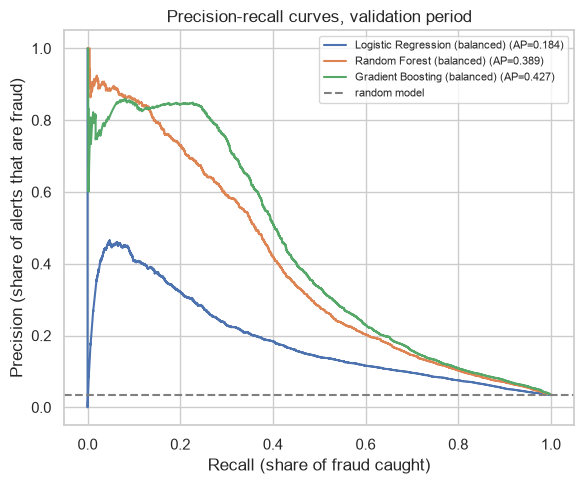

In [25]:
best_model_name = results_df["val_pr_auc"].idxmax()
best_model = fitted[best_model_name]
print("Selected model:", best_model_name)

val_scores = best_model.predict_proba(X_val)[:, 1]
fraud_base_rate = y_val.mean()

fig, ax = plt.subplots(figsize=(6, 5))
curves_to_plot = ["Logistic Regression (balanced)", "Random Forest (balanced)"]
if best_model_name not in curves_to_plot:
    curves_to_plot.append(best_model_name)
for name in curves_to_plot:
    scores = fitted[name].predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, scores)
    ax.plot(recall, precision, label=f"{name} (AP={average_precision_score(y_val, scores):.3f})")
ax.axhline(fraud_base_rate, color="grey", linestyle="--", label="random model")
ax.set_xlabel("Recall (share of fraud caught)")
ax.set_ylabel("Precision (share of alerts that are fraud)")
ax.set_title("Precision-recall curves, validation period")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_pr_curves.png", dpi=120)
plt.show()

**Note on "probability".** With class weights, the model's output is shifted upwards compared with a true fraud probability.
That's why the output is called a **risk score** and every threshold is set on validation data, not taken as a literal probability.

## 5. Threshold and cost analysis

Fraud detection is a decision problem: the model only ranks transactions, the threshold decides who gets stopped.

**Cost assumptions (illustrative):**
- Missed fraud (false negative): we lose the **transaction amount**.
- Alert (any flagged transaction): a fixed review cost covering analyst time and customer friction. Base case **$10**.

Total cost at a threshold = amount of missed fraud + number of alerts × review cost.

Cost with no fraud screening (lose every fraud): $496,908
Lowest cost threshold: 0.50
  total cost $272,368, recall 68.1%, precision 17.3%, alert rate 13.50%


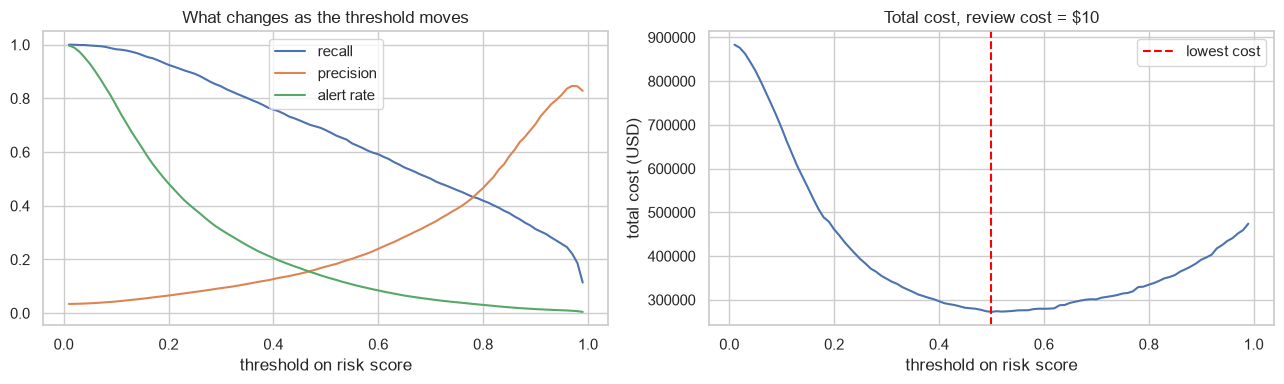

In [26]:
REVIEW_COST = 10
val_amounts = val_df["TransactionAmt"].values
y_val_array = y_val.values

val_costs = cost_curve(y_val_array, val_scores, val_amounts, REVIEW_COST)
best_row = val_costs.loc[val_costs["total_cost"].idxmin()]

no_model_cost = val_amounts[y_val_array == 1].sum()
print(f"Cost with no fraud screening (lose every fraud): ${no_model_cost:,.0f}")
print(f"Lowest cost threshold: {best_row['threshold']:.2f}")
print(f"  total cost ${best_row['total_cost']:,.0f}, recall {best_row['recall']:.1%}, "
      f"precision {best_row['precision']:.1%}, alert rate {best_row['alert_rate']:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(val_costs["threshold"], val_costs["recall"], label="recall")
axes[0].plot(val_costs["threshold"], val_costs["precision"], label="precision")
axes[0].plot(val_costs["threshold"], val_costs["alert_rate"], label="alert rate")
axes[0].set_xlabel("threshold on risk score")
axes[0].set_title("What changes as the threshold moves")
axes[0].legend()
axes[1].plot(val_costs["threshold"], val_costs["total_cost"])
axes[1].axvline(best_row["threshold"], color="red", linestyle="--", label="lowest cost")
axes[1].set_xlabel("threshold on risk score")
axes[1].set_ylabel("total cost (USD)")
axes[1].set_title(f"Total cost, review cost = ${REVIEW_COST}")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_threshold_cost.png", dpi=120)
plt.show()

In [27]:
# The "best" threshold depends on how expensive a review is for the business
sensitivity = []
for review_cost in [2, 5, 10, 25, 50]:
    costs = cost_curve(y_val_array, val_scores, val_amounts, review_cost)
    row = costs.loc[costs["total_cost"].idxmin()]
    sensitivity.append({
        "review_cost": review_cost,
        "best_threshold": row["threshold"],
        "recall": row["recall"],
        "precision": row["precision"],
        "alert_rate": row["alert_rate"],
        "total_cost": row["total_cost"],
        "saving_vs_no_model": no_model_cost - row["total_cost"],
    })
sensitivity_df = pd.DataFrame(sensitivity)
sensitivity_df.to_csv(f"{RESULTS_DIR}/cost_sensitivity.csv", index=False)
sensitivity_df

,review_cost,best_threshold,recall,precision,alert_rate,total_cost,saving_vs_no_model
0,2,0.1800,0.9418,0.0610,0.5302,"112,940.2170","383,967.3710"
1,5,0.3600,0.7926,0.1124,0.2422,"205,146.9040","291,760.6840"
2,10,0.5000,0.6815,0.1734,0.1350,"272,368.4790","224,539.1090"
3,25,0.7600,0.4510,0.4006,0.0387,"367,034.6620","129,872.9260"
4,50,0.8500,0.3728,0.5845,0.0219,"434,185.4950","62,722.0930"


*Interpretation:* when reviews are cheap, the best threshold is low (catch more fraud, accept more alerts).
When reviews are expensive, it moves up. There is no single "correct" threshold — it is a business choice the model makes visible.

## 6. Risk score and decision framework

**Risk score = model score × 100.** Tier cut-offs are derived from the validation period:

| Tier | Rule for the cut-off | Action (illustrative) |
|---|---|---|
| Critical | Lowest score where ≥80% of alerts are real fraud (fallback: top 0.5% of scores) | Hold for manual review |
| High | Lowest-cost threshold from section 5 | Step-up verification |
| Medium | Highest score that still catches 80% of fraud | Approve, monitor |
| Low | Below Medium | Approve automatically |

These actions are analytical recommendations for this project, not any institution's actual policy.

In [28]:
tier_thresholds = choose_tier_thresholds(y_val_array, val_scores, val_amounts, REVIEW_COST)
print({tier: round(value * 100, 1) for tier, value in tier_thresholds.items()})

{'medium': 35.1, 'high': 50.0, 'critical': 94.2}


### Final test on the untouched last 15% of time

In [29]:
test_scores = best_model.predict_proba(X_test)[:, 1]
y_test_array = y_test.values
test_amounts = test_df["TransactionAmt"].values
high_threshold = tier_thresholds["high"]
test_pred = (test_scores >= high_threshold).astype(int)

test_metrics = {
    "model": best_model_name,
    "test_pr_auc": average_precision_score(y_test, test_scores),
    "test_roc_auc": roc_auc_score(y_test, test_scores),
    "test_precision": precision_score(y_test, test_pred),
    "test_recall": recall_score(y_test, test_pred),
    "test_f1": f1_score(y_test, test_pred),
    "test_fraud_rate": y_test.mean(),
    "decision_threshold": high_threshold,
}
for key, value in test_metrics.items():
    print(f"{key:20s} {value}")

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"\nConfusion matrix at the High threshold:  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

test_cost = expected_cost(y_test_array, test_scores, test_amounts, high_threshold, REVIEW_COST)
test_no_model_cost = test_amounts[y_test_array == 1].sum()
fraud_value_caught = test_amounts[(y_test_array == 1) & (test_pred == 1)].sum()
print(f"Fraud value caught: ${fraud_value_caught:,.0f} of ${test_no_model_cost:,.0f} "
      f"({fraud_value_caught / test_no_model_cost:.1%})")
print(f"Total cost with model: ${test_cost:,.0f} vs ${test_no_model_cost:,.0f} with no screening")

model                Gradient Boosting (balanced)
test_pr_auc          0.44508663074534427
test_roc_auc         0.8644826805371397
test_precision       0.15684695894020348
test_recall          0.6951021732079143
test_f1              0.2559417174250567
test_fraud_rate      0.03480430340592226
decision_threshold   0.5

Confusion matrix at the High threshold:  TP=2143  FP=11520  FN=940  TN=73978
Fraud value caught: $302,843 of $469,609 (64.5%)
Total cost with model: $303,396 vs $469,609 with no screening


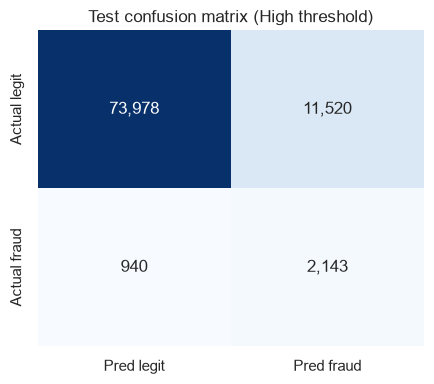

In [30]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt=",", cmap="Blues", cbar=False,
            xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Actual legit", "Actual fraud"], ax=ax)
ax.set_title("Test confusion matrix (High threshold)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_confusion_matrix.png", dpi=120)
plt.show()

In [31]:
scored_test = test_df[["TransactionID", "TransactionDT", "day", "hour", "TransactionAmt", "ProductCD",
                       "card4", "card6", "email_group", "DeviceType", "uid", "isFraud"]].copy()
scored_test["risk_score"] = (test_scores * 100).round(2)
scored_test["risk_tier"] = [assign_tier(s, tier_thresholds) for s in test_scores]
scored_test["recommended_action"] = scored_test["risk_tier"].map(RISK_ACTIONS)

tier_order = ["Low", "Medium", "High", "Critical"]
scored_test["fraud_amount"] = scored_test["TransactionAmt"] * scored_test["isFraud"]
tier_summary = scored_test.groupby("risk_tier").agg(
    transactions=("isFraud", "size"),
    fraud_cases=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    fraud_amount=("fraud_amount", "sum"),
).reindex(tier_order)
tier_summary["share_of_transactions"] = tier_summary["transactions"] / tier_summary["transactions"].sum()
tier_summary["share_of_fraud"] = tier_summary["fraud_cases"] / tier_summary["fraud_cases"].sum()
tier_summary["action"] = [RISK_ACTIONS[t] for t in tier_order]
tier_summary.to_csv(f"{RESULTS_DIR}/tier_summary_test.csv")
tier_summary

,transactions,fraud_cases,fraud_rate,fraud_amount,share_of_transactions,share_of_fraud,action
risk_tier,,,,,,,
Low,64476,601,0.0093,"94,652.9660",0.7279,0.1949,Approve automatically
Medium,10442,339,0.0325,"72,112.7070",0.1179,0.1100,"Approve, but monitor the account"
High,12392,1194,0.0964,"225,479.2110",0.1399,0.3873,Step-up verification (OTP / call-back)
Critical,1271,949,0.7467,"77,363.6370",0.0143,0.3078,Hold transaction for manual review


*Interpretation:* a useful tiering puts a small share of transactions into High/Critical while capturing a large share of fraud,
and leaves the Low tier with a fraud rate well below average so it can be auto-approved.

## 7. Interpretability — why is a transaction risky?

Three views:
1. **Logistic regression coefficients** — direction and strength of each feature (features are standardised, so coefficients are comparable).
2. **Permutation importance** for the selected model — how much validation PR-AUC drops when a feature is shuffled.
3. **Reason codes** for individual transactions — replace one feature at a time with its typical legitimate value and measure how far the score falls.

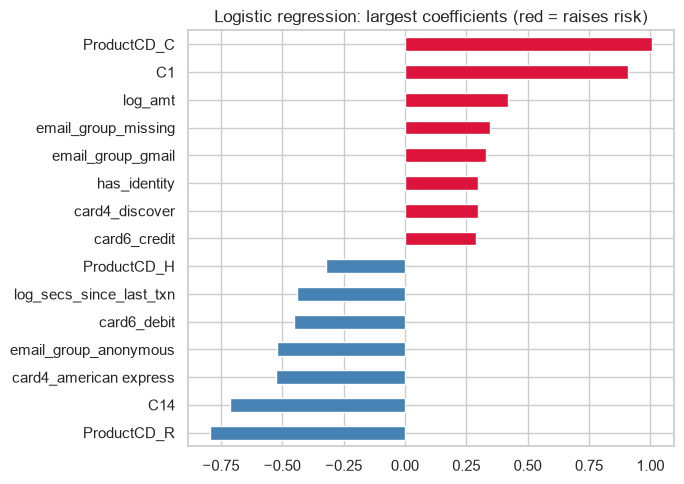

In [32]:
lr_pipe = fitted["Logistic Regression (balanced)"]
coef_names = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=coef_names)
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top_coefs.sort_values().plot.barh(ax=ax, color=["crimson" if c > 0 else "steelblue" for c in top_coefs.sort_values()])
ax.set_title("Logistic regression: largest coefficients (red = raises risk)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_lr_coefficients.png", dpi=120)
plt.show()

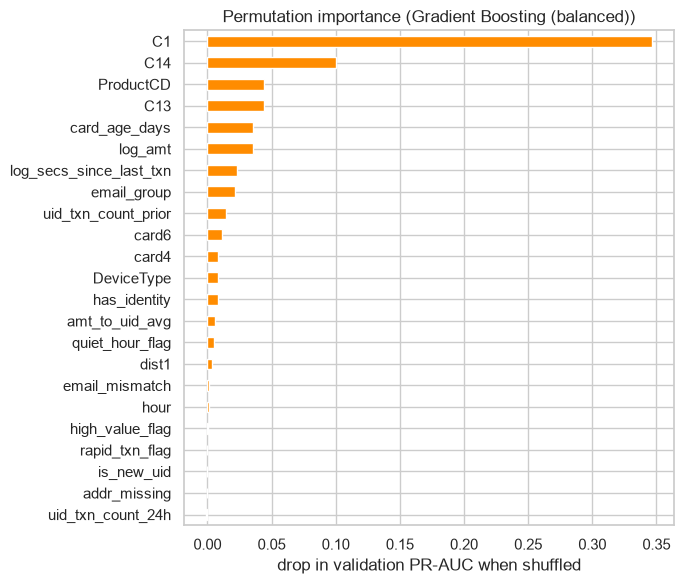

C1                        0.3463
C14                       0.1005
ProductCD                 0.0443
C13                       0.0441
card_age_days             0.0358
log_amt                   0.0351
log_secs_since_last_txn   0.0231
email_group               0.0211
uid_txn_count_prior       0.0146
card6                     0.0111
dtype: float64

In [33]:
# A sample keeps this fast; shuffling one column at a time on 90k rows x 23 features is slow
val_sample = val_df.sample(n=min(30000, len(val_df)), random_state=RANDOM_STATE)
perm = permutation_importance(best_model, val_sample[ALL_FEATURES], val_sample["isFraud"],
                              scoring="average_precision", n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=ALL_FEATURES).sort_values(ascending=False)
importance.to_csv(f"{RESULTS_DIR}/permutation_importance.csv")

fig, ax = plt.subplots(figsize=(7, 6))
importance.sort_values().plot.barh(ax=ax, color="darkorange")
ax.set_title(f"Permutation importance ({best_model_name})")
ax.set_xlabel("drop in validation PR-AUC when shuffled")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_permutation_importance.png", dpi=120)
plt.show()
importance.head(10)

In [34]:
typical = typical_values(train_df)

highest_risk = test_df.loc[scored_test.sort_values("risk_score", ascending=False).index[:3]]
for idx in highest_risk.index:
    row = test_df.loc[[idx]]
    score = scored_test.loc[idx, "risk_score"]
    print(f"TransactionID {row['TransactionID'].iloc[0]} | amount ${row['TransactionAmt'].iloc[0]:,.2f} | "
          f"risk score {score:.1f} ({scored_test.loc[idx, 'risk_tier']}) | actual fraud = {row['isFraud'].iloc[0]}")
    display(explain_transaction(best_model, row, typical))

TransactionID 3499650 | amount $375.00 | risk score 99.8 (Critical) | actual fraud = 1


,feature,value,typical_value,score_drop
6,C1,7.0000,1.0000,0.1385
0,log_amt,5.9296,4.2478,0.0072
9,has_identity,1,0.0000,0.0047


TransactionID 3569809 | amount $400.00 | risk score 99.8 (Critical) | actual fraud = 1


,feature,value,typical_value,score_drop
6,C1,10.0000,1.0000,0.2762
0,log_amt,5.9940,4.2478,0.0197
21,DeviceType,mobile,missing,0.0032


TransactionID 3572525 | amount $150.00 | risk score 99.7 (Critical) | actual fraud = 0


,feature,value,typical_value,score_drop
6,C1,13.0000,1.0000,0.3831
0,log_amt,5.0173,4.2478,0.0181
9,has_identity,1,0.0000,0.0025


## 8. SQL analysis

The transactions and the test-period risk scores are loaded into a local SQLite database, then the queries in
`sql/fraud_analysis.sql` are run. This mirrors how an analyst would pull these numbers from a warehouse.

In [35]:
sql_columns = ["TransactionID", "TransactionDT", "day", "hour", "TransactionAmt", "ProductCD", "card4", "card6",
               "email_group", "DeviceType", "uid", "isFraud", "split"]
conn = sqlite3.connect("../outputs/fraud.db")
df[sql_columns].to_sql("transactions", conn, if_exists="replace", index=False)
scored_test[["TransactionID", "risk_score", "risk_tier"]].to_sql("risk_scores", conn, if_exists="replace", index=False)

with open("../sql/fraud_analysis.sql") as f:
    sql_text = f.read()

for block in sql_text.split(";"):
    query = block.strip()
    if not query:
        continue
    title = query.splitlines()[0].replace("--", "").strip()
    print("\n" + title)
    display(pd.read_sql(query, conn).head(15))


Q1. Portfolio overview: volume, fraud count, fraud rate and value lost


,total_transactions,fraud_transactions,fraud_rate_pct,total_amount,fraud_amount,fraud_value_pct
0,590540,20663,3.5000,"79,738,949.0000","3,083,845.0000",3.8700



Q2. Fraud rate by product segment, ranked


,ProductCD,transactions,fraud_transactions,fraud_rate_pct,risk_rank
0,C,68519,8008,11.6900,1
1,S,11628,686,5.9000,2
2,H,33024,1574,4.7700,3
3,R,37699,1426,3.7800,4
4,W,439670,8969,2.0400,5



Q3. Alternate data: fraud rate by email provider and device type (segments with at least 500 transactions)


...

,flagged_transactions,fraud_among_flagged,fraud_rate_pct
0,6744,277,4.1100



Q9. Test period: risk tier summary joined with actual outcomes


,risk_tier,transactions,actual_fraud,fraud_rate_pct,fraud_amount,share_of_all_fraud_pct
0,Critical,1271,949,74.6700,"77,364.0000",30.8000
1,High,12392,1194,9.6400,"225,479.0000",38.7000
2,Medium,10442,339,3.2500,"72,113.0000",11.0000
3,Low,64476,601,0.9300,"94,653.0000",19.5000



Q10. Alert queue: the 20 highest-risk test transactions


,TransactionID,TransactionAmt,ProductCD,email_group,DeviceType,risk_score,risk_tier,actual_fraud
0,3499650,375.0000,R,gmail,mobile,99.7800,Critical,1
1,3569809,400.0000,R,gmail,mobile,99.7700,Critical,1
2,3504585,200.0000,R,gmail,mobile,99.7300,Critical,1
3,3542862,22.9930,C,gmail,desktop,99.7300,Critical,1
4,3572525,150.0000,H,gmail,mobile,99.7300,Critical,0
5,3495231,39.5930,C,gmail,desktop,99.7200,Critical,1
6,3504590,200.0000,R,gmail,mobile,99.7200,Critical,1
7,3542851,22.9930,C,gmail,desktop,99.7200,Critical,1
8,3547513,62.9560,C,microsoft,mobile,99.7100,Critical,1
9,3490488,175.9560,C,gmail,desktop,99.7000,Critical,1


## 9. Save outputs

- `model_bundle.joblib`: the model plus everything the dashboard needs to score a transaction the same way.
- `scored_test_transactions.csv`: test-period transactions with risk score, tier and action. This is also the file to load into **Power BI / Tableau**.
- `key_results.json`: the headline numbers used in the README.

In [36]:
bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "tier_thresholds": tier_thresholds,
    "typical_values": typical,
    "quiet_hours": quiet_hours,
    "high_value_cutoff": float(high_value_cutoff),
    "review_cost": REVIEW_COST,
}
joblib.dump(bundle, f"{RESULTS_DIR}/model_bundle.joblib")

scored_test.to_csv(f"{RESULTS_DIR}/scored_test_transactions.csv", index=False)

# Feature rows for the dashboard's scoring page (test period only, to keep the file small)
dashboard_columns = ["TransactionID", "uid", "TransactionAmt", "uid_avg_amt_prior", "secs_since_last_txn",
                     "P_emaildomain", "R_emaildomain", "isFraud"] + ALL_FEATURES
test_df[dashboard_columns].to_csv(f"{RESULTS_DIR}/test_features.csv", index=False)

key_results = {
    "rows": int(len(df)),
    "fraud_rate": float(df["isFraud"].mean()),
    "customers_proxy": int(df["uid"].nunique()),
    "n_features": len(ALL_FEATURES),
    "train_rows": int(len(train_df)), "val_rows": int(len(val_df)), "test_rows": int(len(test_df)),
    "selected_model": best_model_name,
    "val_pr_auc": float(results_df.loc[best_model_name, "val_pr_auc"]),
    "baseline_lr_val_pr_auc": float(results_df.loc["Logistic Regression (balanced)", "val_pr_auc"]),
    **{k: float(v) for k, v in test_metrics.items() if k != "model"},
    "tier_thresholds_score": {k: round(v * 100, 2) for k, v in tier_thresholds.items()},
    "test_fraud_value_caught_pct": float(fraud_value_caught / test_no_model_cost),
    "test_cost_with_model": float(test_cost),
    "test_cost_no_model": float(test_no_model_cost),
    "high_critical_share_of_txns": float(tier_summary.loc[["High", "Critical"], "transactions"].sum() / len(test_df)),
    "high_critical_share_of_fraud": float(tier_summary.loc[["High", "Critical"], "fraud_cases"].sum() / max(y_test.sum(), 1)),
}
with open(f"{RESULTS_DIR}/key_results.json", "w") as f:
    json.dump(key_results, f, indent=2)
key_results

{'rows': 590540,
 'fraud_rate': 0.03499000914417313,
 'customers_proxy': 217779,
 'n_features': 23,
 'train_rows': 413378,
 'val_rows': 88581,
 'test_rows': 88581,
 'selected_model': 'Gradient Boosting (balanced)',
 'val_pr_auc': 0.4265682914189756,
 'baseline_lr_val_pr_auc': 0.1836063451805538,
 'test_pr_auc': 0.44508663074534427,
 'test_roc_auc': 0.8644826805371397,
 'test_precision': 0.15684695894020348,
 'test_recall': 0.6951021732079143,
 'test_f1': 0.2559417174250567,
 'test_fraud_rate': 0.03480430340592226,
 'decision_threshold': 0.5,
 'tier_thresholds_score': {'medium': 35.09, 'high': 50.0, 'critical': 94.21},
 'test_fraud_value_caught_pct': 0.6448836306358249,
 'test_cost_with_model': 303395.673,
 'test_cost_no_model': 469608.52099999995,
 'high_critical_share_of_txns': 0.15424300922319684,
 'high_critical_share_of_fraud': 0.6951021732079143}

## 10. Final audit

In [37]:
checks = {
    "History features use only past rows (first txn has 0 prior count)":
        df.groupby("uid").head(1)["uid_txn_count_prior"].max() == 0,
    "Train, validation, test are in time order":
        train_df["TransactionDT"].max() <= val_df["TransactionDT"].min() <= test_df["TransactionDT"].min(),
    "Quiet hours / high-value cut-off computed on train period only": True,
    "Thresholds chosen on validation, test used once": True,
    "No TransactionID appears in two splits":
        len(set(train_df["TransactionID"]) & set(test_df["TransactionID"])) == 0,
    "Model selected on PR-AUC, not accuracy": True,
}
for check, passed in checks.items():
    print("PASS" if passed else "FAIL", "-", check)

print()
print(results_df[["train_pr_auc", "val_pr_auc", "overfit_gap"]])
print(f"Selected model test PR-AUC: {test_metrics['test_pr_auc']:.4f}")

PASS - History features use only past rows (first txn has 0 prior count)
PASS - Train, validation, test are in time order
PASS - Quiet hours / high-value cut-off computed on train period only
PASS - Thresholds chosen on validation, test used once
PASS - No TransactionID appears in two splits
PASS - Model selected on PR-AUC, not accuracy

                                  train_pr_auc  val_pr_auc  overfit_gap
model                                                                  
Logistic Regression (no weights)        0.1977      0.2646      -0.0670
Logistic Regression (balanced)          0.1428      0.1836      -0.0408
Decision Tree (balanced)                0.3938      0.3512       0.0426
Random Forest (balanced)                0.4880      0.3886       0.0994
Gradient Boosting (balanced)            0.5604      0.4266       0.1338
Selected model test PR-AUC: 0.4451


## Key takeaways

The numbers for this section come from `outputs/model_results/key_results.json` and the tables above.
They are summarised in the README.